# 04 -- Luck Score Demo (Version 0.2: fixed run values + empirical score)

**Contact Luck Prototype v0.2**

Version 0.2 replaces both Version 0.1 placeholders:

1. The 0-4 ordinal outcome map -> a **fixed, context-neutral run-value table** derived from published FanGraphs Guts constants (2021-2024 average).
2. The arbitrary `tanh` public-score mapping -> an **empirical signed-percentile score** built from genuinely out-of-sample 2024 raw-luck values (never 2025, never the training data).

This notebook is strictly time-ordered, exactly as in Version 0.1:
- The model trains ONLY on `TRAIN_SEASONS` (2021-2023).
- The example play and the empirical-score reference distribution are both drawn ONLY from `VALIDATION_SEASONS` (2024).
- Neither is ever part of training.
- 2025 is never loaded or used.

**This is Contact Luck Version 0.2, not the final TrueLuck metric** -- weather, park effects, exact defensive positioning, defensive execution, and baserunning decision/execution are not yet separated out. See README.md "Future work".

If the full development dataset is missing, this notebook falls back to a small synthetic example (never to the one-week sample) so the pipeline is always runnable, though the empirical score needs enough reference rows and may be unavailable in that case.

> **This repository is a research prototype, not a validated public baseball statistic.** See `README.md` and `CLAUDE.md` for full scope and limitations.

In [1]:
import numpy as np
import pandas as pd

from mlb_luck_score.config import (
    CLASS_ORDER,
    DEFAULT_VALUE_MAP,
    PROCESSED_DATA_DIR,
    ARTIFACTS_DIR,
    TRAIN_SEASONS,
    VALIDATION_SEASONS,
    assert_seasons_allowed,
)
from mlb_luck_score.models.build_reference_score import build_reference_artifact
from mlb_luck_score.models.predict_outcomes import _build_synthetic_demo_data
from mlb_luck_score.models.train_contact_model import predict_proba_ordered, train_model
from mlb_luck_score.scoring.confidence import compute_confidence
from mlb_luck_score.scoring.contact_luck import compute_expected_run_value, compute_raw_contact_luck_runs
from mlb_luck_score.scoring.empirical_score import (
    compute_empirical_public_score,
    compute_empirical_public_scores,
    load_reference_artifact,
)
from mlb_luck_score.scoring.public_score import raw_luck_to_public_score  # LEGACY (Version 0.1)
from mlb_luck_score.scoring.raw_luck import compute_raw_luck  # LEGACY (Version 0.1)
from mlb_luck_score.scoring.run_values import DEFAULT_RUN_VALUE_MAP

DEVELOPMENT_PATH = PROCESSED_DATA_DIR / "cleaned_development_data.parquet"
SAMPLE_PATH = PROCESSED_DATA_DIR / "cleaned_batted_balls.parquet"
REFERENCE_ARTIFACT_PATH = ARTIFACTS_DIR / "reference_score_v0.2.0.json"
pd.set_option("display.width", 120)

## The Version 0.2 fixed run-value table

Computed programmatically from published FanGraphs Guts constants (see `mlb_luck_score.scoring.run_values`) -- the arithmetic mean of 2021-2024. Shown alongside the Version 0.1 legacy ordinal map for comparison: notice the Version 0.2 table is NOT evenly spaced (a home run is worth much more than 4x an out, and a triple and double are much closer together than their ordinal ranks 3 and 2 suggest).

In [2]:
run_value_comparison = pd.DataFrame(
    {
        "v0.2 fixed run value (runs)": DEFAULT_RUN_VALUE_MAP,
        "v0.1 legacy ordinal value": DEFAULT_VALUE_MAP,
    }
).reindex(list(CLASS_ORDER))
display(run_value_comparison)

,v0.2 fixed run value (runs),v0.1 legacy ordinal value
out,-0.254916,0.0
single,0.463266,1.0
double,0.763026,2.0
triple,1.033068,3.0
home_run,1.400288,4.0


## Load data

Prefers the full 2021-2024 development dataset. Falls back to a small synthetic example ONLY when that dataset is missing -- **never** to the one-week sample (see the printed message below for why).

In [3]:
using_synthetic = False
if DEVELOPMENT_PATH.exists():
    df = pd.read_parquet(DEVELOPMENT_PATH)
    print(f"Loaded the full development dataset: {len(df)} rows from {DEVELOPMENT_PATH}")
else:
    df = None
    using_synthetic = True
    if SAMPLE_PATH.exists():
        print(
            "WARNING: full development dataset not found, but the one-week sample "
            f"exists at {SAMPLE_PATH}. This notebook does NOT fall back to it -- the "
            "sample only covers 7 days of 2024 and cannot provide any 2021-2023 "
            "training rows, which would break the time-ordered design this notebook "
            "demonstrates. Falling back to synthetic demo data instead.\n"
            "Run `make download-development-data` then `make clean-development-data` "
            "for a real 2021-2024 walkthrough."
        )
    else:
        print(
            f"No full development dataset found at {DEVELOPMENT_PATH}.\n"
            "Falling back to synthetic demo data. Run `make download-development-data` "
            "then `make clean-development-data` for a real 2021-2024 walkthrough."
        )

Loaded the full development dataset: 494173 rows from /Users/arihantaneja/Downloads/TrueLuckMLBStat/data/processed/cleaned_development_data.parquet


## Filter to training-eligible rows, guard 2025, and split by season

The explicit `assert_seasons_allowed` call is a defense-in-depth check: this notebook only ever requests `TRAIN_SEASONS`/`VALIDATION_SEASONS` (2021-2024), so 2025 should never appear.

In [4]:
if using_synthetic:
    # Fabricated data has no real seasons -- assign a synthetic season split so the
    # SAME time-ordered code path below runs for both real and synthetic data.
    training_eligible = _build_synthetic_demo_data()
    training_eligible["eligible_for_training"] = True
    training_eligible["season"] = TRAIN_SEASONS[0]
    training_eligible.loc[training_eligible.index[-1:], "season"] = VALIDATION_SEASONS[0]
    for col in ("game_date", "batter", "pitcher", "description", "player_name"):
        if col not in training_eligible.columns:
            training_eligible[col] = "(synthetic -- not available)"
else:
    assert_seasons_allowed(sorted(df["season"].dropna().unique().tolist()))
    print("Confirmed: no 2025 data present in the loaded dataset.")
    training_eligible = df[df["eligible_for_training"].astype(bool)].copy()

train_df = training_eligible[training_eligible["season"].isin(TRAIN_SEASONS)]
val_df = training_eligible[training_eligible["season"].isin(VALIDATION_SEASONS)]

print(f"Training rows ({TRAIN_SEASONS}): {len(train_df)}")
print(f"Validation rows ({VALIDATION_SEASONS}): {len(val_df)}")
assert len(train_df) > 0, "No training rows available -- cannot proceed."
assert len(val_df) > 0, "No validation rows available -- cannot proceed."
assert train_df["season"].isin(TRAIN_SEASONS).all()
assert val_df["season"].isin(VALIDATION_SEASONS).all()
assert set(train_df.index).isdisjoint(val_df.index), (
    "Training and validation rows must never overlap."
)

Confirmed: no 2025 data present in the loaded dataset.


Training rows ((2021, 2022, 2023)): 364311
Validation rows ((2024,)): 122132


## Train the unweighted baseline on 2021-2023 ONLY

**The probability below comes from the `unweighted` model (`class_weight=None`) -- the variant selected as the Contact Luck probability baseline in `03_calibration.ipynb`.**

In [5]:
trained = train_model(train_df, class_weight=None)
print("Variant:", trained.variant)
print("class_weight:", trained.class_weight)
print("Numeric features:", trained.numeric_features)
print("Categorical features:", trained.categorical_features)

Variant: unweighted_probability_baseline
class_weight: None
Numeric features: ['launch_speed', 'launch_angle', 'spray_angle_approx', 'hit_distance_sc']
Categorical features: ['bb_type', 'stand']


## Select the example play from 2024 ONLY

Chosen as the first `home_run` row in the 2024 validation split (if any) purely for an illustrative example with a clearly favorable outcome -- not cherry-picked for a large raw-luck value across many candidates. **This row was never seen during training, and is never part of the empirical-score reference sample used to score it** (see below).

In [6]:
home_run_candidates = val_df[val_df["outcome_class"] == "home_run"]
example = (home_run_candidates if not home_run_candidates.empty else val_df).iloc[[0]].copy()
observed_outcome = str(example["outcome_class"].iloc[0])
example_season = int(example["season"].iloc[0])

assert example_season in VALIDATION_SEASONS, "Example must come from a validation season."
assert example.index[0] not in train_df.index, "Example must never be a training row."

feature_cols = trained.numeric_features + trained.categorical_features
proba_df = predict_proba_ordered(trained, example[feature_cols])
probabilities = {cls: float(proba_df.iloc[0][cls]) for cls in CLASS_ORDER}

## Play details

In [7]:
def _display_value(row, col):
    if col in row.index and pd.notna(row[col]):
        return row[col]
    return "(not available)"

row = example.iloc[0]
print(f"Season:                  {example_season}")
print(f"Game date:               {_display_value(row, 'game_date')}")
print(f"Batter ID:               {_display_value(row, 'batter')}")
print(f"Pitcher ID:              {_display_value(row, 'pitcher')}")
# NOTE: Statcast's `player_name` field identifies the PITCHER, not the batter
# (verified against real data). There is no batter-name field in this schema.
print(f"Pitcher name:            {_display_value(row, 'player_name')}")
print(f"Event description:       {_display_value(row, 'description')}")
print(f"Actual outcome:          {observed_outcome}")

Season:                  2024
Game date:               2024-09-26
Batter ID:               592669
Pitcher ID:              571578
Pitcher name:            Corbin, Patrick
Event description:       hit_into_play
Actual outcome:          home_run


## Version 0.2 scoring walkthrough (fixed run values + empirical percentile score)

**The probability distribution below comes from the `unweighted` baseline selected in `03_calibration.ipynb`.** Run values are the fixed, context-neutral FanGraphs-derived table above -- NOT adjusted for this specific play's base/out state, score, or win probability.

In [8]:
expected_run_value = compute_expected_run_value(probabilities)
actual_run_value = DEFAULT_RUN_VALUE_MAP[observed_outcome]
raw_contact_luck_runs = compute_raw_contact_luck_runs(probabilities, observed_outcome)

print("Predicted probability distribution (unweighted baseline):")
for cls in CLASS_ORDER:
    print(f"  {cls:>9s}: {probabilities[cls]:.3f}  (run value {DEFAULT_RUN_VALUE_MAP[cls]:+.3f})")
print(f"P(observed result):                {probabilities[observed_outcome]:.3f}")
print(f"Expected run value:                {expected_run_value:+.4f} runs")
print(f"Actual run value ({observed_outcome}):        {actual_run_value:+.4f} runs")
print(f"Raw contact luck (additive):       {raw_contact_luck_runs:+.4f} runs")

Predicted probability distribution (unweighted baseline):
        out: 0.038  (run value -0.255)
     single: 0.001  (run value +0.463)
     double: 0.014  (run value +0.763)
     triple: 0.003  (run value +1.033)
   home_run: 0.944  (run value +1.400)
P(observed result):                0.944
Expected run value:                +1.3264 runs
Actual run value (home_run):        +1.4003 runs
Raw contact luck (additive):       +0.0739 runs


In [9]:
# IMPORTANT: only ever load/build a reference artifact when using real data --
# scoring a synthetic example against the REAL 2024 reference distribution would
# silently mix fabricated and real data, which is exactly the kind of inconsistency
# this notebook must not produce.
if using_synthetic:
    reference_artifact = None
    print(
        "Skipping empirical score -- synthetic demo data does not have enough "
        "reference rows to build a two-sided (positive and negative) empirical "
        "percentile mapping, and scoring a synthetic example against the real "
        "2024 reference distribution would mix fabricated and real data."
    )
elif REFERENCE_ARTIFACT_PATH.exists():
    reference_artifact = load_reference_artifact(REFERENCE_ARTIFACT_PATH)
    print(f"Loaded reference artifact from {REFERENCE_ARTIFACT_PATH}")
else:
    print(
        f"No reference artifact found at {REFERENCE_ARTIFACT_PATH}; building one now "
        "(run `make build-reference-score` to persist it for reuse)."
    )
    reference_artifact = build_reference_artifact(df)

if reference_artifact is not None:
    assert reference_artifact.training_seasons == tuple(TRAIN_SEASONS)
    assert reference_artifact.reference_seasons == tuple(VALIDATION_SEASONS)
    assert "balanced" not in reference_artifact.model_variant
    print("Reference sample counts:", reference_artifact.sample_counts)
    empirical_public_score = compute_empirical_public_score(raw_contact_luck_runs, reference_artifact)
    confidence = compute_confidence(row)

    print(f"\nEmpirical public score:            {empirical_public_score:+.1f} / 100")
    if empirical_public_score > 0:
        print(
            f"Interpretation: more favorable raw luck than ~{empirical_public_score:.0f}% "
            "of positive-luck 2024 reference plays."
        )
    elif empirical_public_score < 0:
        print(
            f"Interpretation: greater unfavorable-luck magnitude than "
            f"~{abs(empirical_public_score):.0f}% of negative-luck 2024 reference plays."
        )
    else:
        print("Interpretation: exactly at expectation (raw luck == 0).")
    print(f"Data-completeness label:           {confidence.label}")
    print(f"Data-completeness detail:          {confidence}")
else:
    confidence = compute_confidence(row)
    print(f"Data-completeness label: {confidence.label}")

Loaded reference artifact from /Users/arihantaneja/Downloads/TrueLuckMLBStat/artifacts/reference_score_v0.2.0.json
Reference sample counts: {'total': 122132, 'positive': 39196, 'negative': 82936, 'zero': 0}

Empirical public score:            +2.6 / 100
Interpretation: more favorable raw luck than ~3% of positive-luck 2024 reference plays.
Data-completeness label:           medium_data_completeness
Data-completeness detail:          ConfidenceReport(required_fields_present_pct=71.42857142857143, missing_optional_fields=('venue', 'sprint_speed'), spray_direction_available=False, park_available=False, alignment_fields_available=True, fully_eligible=True, label='medium_data_completeness')


## Legacy Version 0.1 comparison (for reference only -- NOT the main output)

The ordinal value map and `tanh` public score are superseded by the Version 0.2 run-value table and empirical percentile score above. Shown here ONLY to make the difference concrete for the SAME example play.

In [10]:
legacy_expected_value = sum(probabilities[c] * DEFAULT_VALUE_MAP[c] for c in CLASS_ORDER)
legacy_actual_value = DEFAULT_VALUE_MAP[observed_outcome]
legacy_raw_luck = compute_raw_luck(probabilities, observed_outcome, value_map=DEFAULT_VALUE_MAP)
legacy_public_score = raw_luck_to_public_score(legacy_raw_luck)

print("[LEGACY v0.1] Expected ordinal value: ", f"{legacy_expected_value:.3f}")
print("[LEGACY v0.1] Actual ordinal value:   ", f"{legacy_actual_value:.3f}")
print("[LEGACY v0.1] Raw luck (ordinal):     ", f"{legacy_raw_luck:+.3f}")
print("[LEGACY v0.1] tanh public score:       ", f"{legacy_public_score:+.1f} / 100 (superseded, NOT additive)")

[LEGACY v0.1] Expected ordinal value:  3.814
[LEGACY v0.1] Actual ordinal value:    4.000
[LEGACY v0.1] Raw luck (ordinal):      +0.186
[LEGACY v0.1] tanh public score:        +9.3 / 100 (superseded, NOT additive)


## 2024 reference distribution summary

The full out-of-sample 2024 raw-contact-luck distribution used to build the empirical percentile mapping above (unweighted baseline, trained on 2021-2023 only). This is the SAME reference distribution `03_calibration.ipynb`'s probability-quality analysis is built on top of, viewed here in raw-luck-runs terms.

In [11]:
if reference_artifact is not None and not using_synthetic:
    training_eligible_2024 = training_eligible[training_eligible["eligible_for_training"].astype(bool)]
    reference_df = training_eligible_2024[training_eligible_2024["season"].isin(VALIDATION_SEASONS)]
    reference_feature_cols = trained.numeric_features + trained.categorical_features
    reference_proba = predict_proba_ordered(trained, reference_df[reference_feature_cols])
    run_value_series = pd.Series(DEFAULT_RUN_VALUE_MAP).reindex(list(CLASS_ORDER))
    reference_expected = reference_proba[list(CLASS_ORDER)].to_numpy() @ run_value_series.to_numpy()
    reference_actual = reference_df["outcome_class"].astype(str).map(DEFAULT_RUN_VALUE_MAP).to_numpy()
    reference_raw_luck = reference_actual - reference_expected

    summary = {
        "count": len(reference_raw_luck),
        "mean": float(np.mean(reference_raw_luck)),
        "median": float(np.median(reference_raw_luck)),
        "std": float(np.std(reference_raw_luck)),
        "min": float(np.min(reference_raw_luck)),
        "max": float(np.max(reference_raw_luck)),
        "positive_count": int((reference_raw_luck > 0).sum()),
        "negative_count": int((reference_raw_luck < 0).sum()),
        "zero_count": int((reference_raw_luck == 0).sum()),
    }
    display(pd.Series(summary))

    quantile_points = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    display(
        pd.Series(
            np.quantile(reference_raw_luck, quantile_points),
            index=[f"p{int(q * 100)}" for q in quantile_points],
            name="raw_contact_luck_runs",
        )
    )
else:
    reference_raw_luck = None
    print("Skipped -- no reference distribution available (synthetic fallback).")

count             122132.000000
mean                  -0.001949
median                -0.096855
std                    0.367529
min                   -1.545572
max                    1.573211
positive_count     39196.000000
negative_count     82936.000000
zero_count             0.000000
dtype: float64

p5    -0.527819
p10   -0.429619
p25   -0.200393
p50   -0.096855
p75    0.237690
p90    0.520616
p95    0.637629
Name: raw_contact_luck_runs, dtype: float64

### Histogram: raw contact luck (runs)

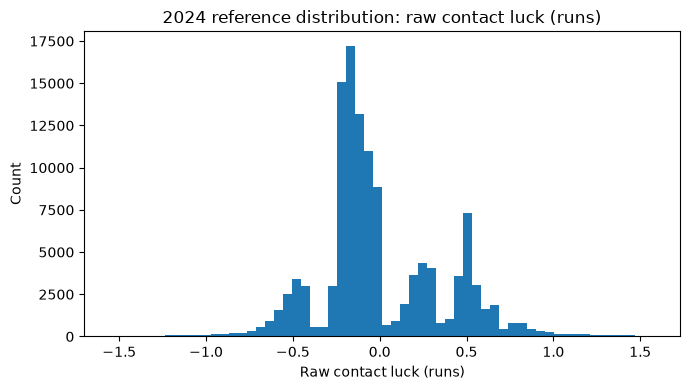

In [12]:
if reference_raw_luck is not None:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(reference_raw_luck, bins=60)
    ax.set_xlabel("Raw contact luck (runs)")
    ax.set_ylabel("Count")
    ax.set_title("2024 reference distribution: raw contact luck (runs)")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped -- no reference distribution available.")

### Histogram: empirical public scores

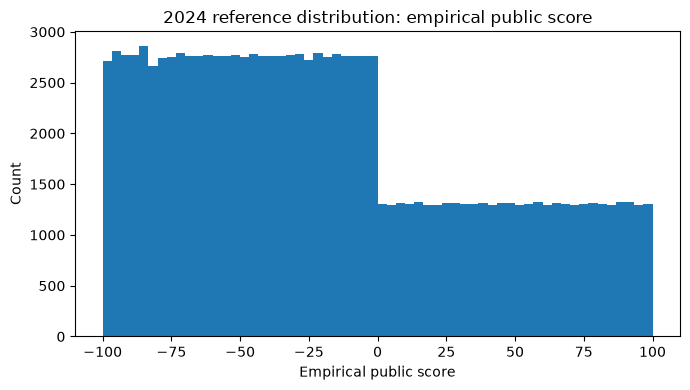

Note: this histogram is a DIAGNOSTIC of the per-play score distribution -- never sum or average these scores to build a season metric (see mlb_luck_score.scoring.aggregation, which operates on raw-luck runs only).


In [13]:
if reference_raw_luck is not None:
    reference_scores = compute_empirical_public_scores(reference_raw_luck, reference_artifact)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(reference_scores, bins=60)
    ax.set_xlabel("Empirical public score")
    ax.set_ylabel("Count")
    ax.set_title("2024 reference distribution: empirical public score")
    plt.tight_layout()
    plt.show()
    print(
        "Note: this histogram is a DIAGNOSTIC of the per-play score distribution -- "
        "never sum or average these scores to build a season metric (see "
        "mlb_luck_score.scoring.aggregation, which operates on raw-luck runs only)."
    )
else:
    print("Skipped -- no reference distribution available.")

## Explicit provisional disclaimer

- **This is Contact Luck Version 0.2, not the final TrueLuck metric.** Weather, park effects, exact defensive positioning, defensive execution, and baserunning decision/execution are not yet separated out -- see README.md "Future work".
- The fixed run-value table is **context-neutral**: it does not use this (or any) play's actual base/out state, runs scored, win probability, or RE24. A bases-loaded triple and a bases-empty triple get the identical run value here.
- The empirical public score's percentile mapping is only as good as its reference sample (2024 unweighted-baseline predictions) -- it is **not** refit on 2025, and values far outside the historical range are clipped to +-100.
- The empirical score is **NOT additive** -- do not sum public scores across plays or seasons; use raw contact luck (runs) for that (see `mlb_luck_score.scoring.aggregation`).
- The confidence label reflects **observable data completeness only** -- it does not affect (and should never affect) raw luck or the public score.
- The underlying `unweighted` model itself has known, small remaining calibration imperfections (see notebook 03) -- this is a Version 0.2 research artifact, not a validated statistic.

> **This repository is a research prototype, not a validated public baseball statistic.** See `README.md` and `CLAUDE.md` for full scope and limitations.